1. Importing packages and creating folders

In [3]:
from pathlib import Path
import subprocess
import json
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

raw_dir = Path("data/subset_raw")
clean_dir = Path("data/clean")
report_dir = Path("data/fastp_reports")
reference_dir = Path("data/reference")
quant_dir = Path("data/quant")
results_dir = Path("results")

for folder in [
    raw_dir,
    clean_dir,
    report_dir,
    reference_dir,
    quant_dir,
    results_dir,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready.")

Project folders are ready.


2. Retrieving the metadata from the 12 samples

TSV file with TPM valus 

In [9]:
ena_url = (
    "https://www.ebi.ac.uk/ena/portal/api/filereport"
    "?accession=PRJNA1194989"
    "&result=read_run"
    "&fields=run_accession,sample_accession,experiment_title,library_layout"
    "&format=tsv"
)

samples = pd.read_csv(ena_url, sep="\t")

samples["sample_name"] = samples["experiment_title"].str.extract(
    r"GSM\d+:\s+(\S+)"
)

samples["condition"] = (
    samples["sample_name"]
    .str.replace(r"_\d+$", "", regex=True)
    .str.replace("624Mel_", "", regex=False)
)

samples["replicate"] = (
    samples["sample_name"]
    .str.extract(r"_(\d+)$")[0]
    .astype(int)
)

samples = samples.sort_values(
    ["condition", "replicate"]
).reset_index(drop=True)

display(
    samples[
        [
            "run_accession",
            "sample_name",
            "condition",
            "replicate",
            "library_layout",
        ]
    ]
)

print("Number of samples:", len(samples))

,run_accession,sample_name,condition,replicate,library_layout
0,SRR31631262,624Mel_siCTRL_1,siCTRL,1,PAIRED
1,SRR31631258,624Mel_siCTRL_2,siCTRL,2,PAIRED
2,SRR31631254,624Mel_siCTRL_3,siCTRL,3,PAIRED
3,SRR31631261,624Mel_siCTRL+IFNg_1,siCTRL+IFNg,1,PAIRED
4,SRR31631257,624Mel_siCTRL+IFNg_2,siCTRL+IFNg,2,PAIRED
5,SRR31631253,624Mel_siCTRL+IFNg_3,siCTRL+IFNg,3,PAIRED
6,SRR31631260,624Mel_siMITF_1,siMITF,1,PAIRED
7,SRR31631256,624Mel_siMITF_2,siMITF,2,PAIRED
8,SRR31631252,624Mel_siMITF_3,siMITF,3,PAIRED
9,SRR31631259,624Mel_siMITF+IFNg_1,siMITF+IFNg,1,PAIRED


Number of samples: 12


3. Downloading 1000000 reads from all 12 samples

SRA files 

In [3]:
max_spots = 1_000_000

for run in samples["run_accession"]:
    read1 = raw_dir / f"{run}_1.fastq.gz"
    read2 = raw_dir / f"{run}_2.fastq.gz"

    if read1.exists() and read2.exists():
        print(f"{run}: files already exist — skipping")
        continue

    print(f"Retrieving {max_spots:,} paired spots from {run}...")

    subprocess.run(
        [
            "fastq-dump",
            "-N", "1",
            "-X", str(max_spots),
            "--split-files",
            "--gzip",
            "--outdir", str(raw_dir),
            run,
        ],
        check=True,
    )

print("Subset retrieval complete.")

Retrieving 1,000,000 paired spots from SRR31631262...
Read 1000000 spots for SRR31631262
Written 1000000 spots for SRR31631262
Retrieving 1,000,000 paired spots from SRR31631258...
Read 1000000 spots for SRR31631258
Written 1000000 spots for SRR31631258
Retrieving 1,000,000 paired spots from SRR31631254...
Read 1000000 spots for SRR31631254
Written 1000000 spots for SRR31631254
Retrieving 1,000,000 paired spots from SRR31631261...
Read 1000000 spots for SRR31631261
Written 1000000 spots for SRR31631261
Retrieving 1,000,000 paired spots from SRR31631257...
Read 1000000 spots for SRR31631257
Written 1000000 spots for SRR31631257
Retrieving 1,000,000 paired spots from SRR31631253...
Read 1000000 spots for SRR31631253
Written 1000000 spots for SRR31631253
Retrieving 1,000,000 paired spots from SRR31631260...
Read 1000000 spots for SRR31631260
Written 1000000 spots for SRR31631260
Retrieving 1,000,000 paired spots from SRR31631256...
Read 1000000 spots for SRR31631256
Written 1000000 spots 

4. Confirming the raw FASTQs; 24 in total, one reverse and one forward FASTQ from each sample

In [4]:
raw_fastqs = sorted(raw_dir.glob("*.fastq.gz"))

print("Raw FASTQ files:", len(raw_fastqs))

assert len(samples) == 12, "Expected 12 samples."
assert len(raw_fastqs) == 24, "Expected 24 paired-end FASTQ files."

for run in samples["run_accession"]:
    assert (raw_dir / f"{run}_1.fastq.gz").exists()
    assert (raw_dir / f"{run}_2.fastq.gz").exists()

print("All 12 paired-end samples are present.")

Raw FASTQ files: 24
All 12 paired-end samples are present.


5. Using FASTP to clean pair end reads; resulting in clean FASTQs and QC reports.

In [5]:
for run in samples["run_accession"]:
    input_r1 = raw_dir / f"{run}_1.fastq.gz"
    input_r2 = raw_dir / f"{run}_2.fastq.gz"

    output_r1 = clean_dir / f"{run}_1.clean.fastq.gz"
    output_r2 = clean_dir / f"{run}_2.clean.fastq.gz"

    json_report = report_dir / f"{run}.fastp.json"
    html_report = report_dir / f"{run}.fastp.html"

    if (
        output_r1.exists()
        and output_r2.exists()
        and json_report.exists()
        and html_report.exists()
    ):
        print(f"{run}: already cleaned — skipping")
        continue

    print(f"Cleaning {run}...")

    subprocess.run(
        [
            "fastp",
            "--in1", str(input_r1),
            "--in2", str(input_r2),
            "--out1", str(output_r1),
            "--out2", str(output_r2),
            "--json", str(json_report),
            "--html", str(html_report),
            "--detect_adapter_for_pe",
            "--thread", "4",
        ],
        check=True,
    )

print("Cleaning complete.")

Cleaning SRR31631262...


Detecting adapter sequence for read1...
>Illumina TruSeq Adapter Read 1
AGATCGGAAGAGCACACGTCTGAACTCCAGTCA

Detecting adapter sequence for read2...
>Illumina TruSeq Adapter Read 2
AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 1000000
total bases: 125000000
Q20 bases: 123312436(98.6499%)
Q30 bases: 120357370(96.2859%)

Read2 before filtering:
total reads: 1000000
total bases: 125000000
Q20 bases: 122890277(98.3122%)
Q30 bases: 119404394(95.5235%)

Read1 after filtering:
total reads: 991435
total bases: 123501739
Q20 bases: 122079022(98.848%)
Q30 bases: 119241095(96.5501%)

Read2 after filtering:
total reads: 991435
total bases: 123502701
Q20 bases: 121939913(98.7346%)
Q30 bases: 118621518(96.0477%)

Filtering result:
reads passed filter: 1982870
reads failed due to low quality: 16636
reads failed due to too many N: 0
reads failed due to too short: 494
reads with adapter trimmed: 49237
bases trimmed due to adapters: 903889

Duplication rate: 28.4395%

Insert size

Cleaning SRR31631258...


>Illumina TruSeq Adapter Read 1
AGATCGGAAGAGCACACGTCTGAACTCCAGTCA

Detecting adapter sequence for read2...
>Illumina TruSeq Adapter Read 2
AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 1000000
total bases: 125000000
Q20 bases: 123368927(98.6951%)
Q30 bases: 120583393(96.4667%)

Read2 before filtering:
total reads: 1000000
total bases: 125000000
Q20 bases: 122622187(98.0977%)
Q30 bases: 119036618(95.2293%)

Read1 after filtering:
total reads: 989461
total bases: 123204939
Q20 bases: 121863988(98.9116%)
Q30 bases: 119206507(96.7546%)

Read2 after filtering:
total reads: 989461
total bases: 123207430
Q20 bases: 121496045(98.611%)
Q30 bases: 118118618(95.8697%)

Filtering result:
reads passed filter: 1978922
reads failed due to low quality: 20668
reads failed due to too many N: 0
reads failed due to too short: 410
reads with adapter trimmed: 53044
bases trimmed due to adapters: 1001711

Duplication rate: 25.7227%

Insert size peak (evaluated by paired-end reads): 

Cleaning SRR31631254...


...

>Illumina TruSeq Adapter Read 1
AGATCGGAAGAGCACACGTCTGAACTCCAGTCA

Detecting adapter sequence for read2...
>Illumina TruSeq Adapter Read 2
AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 1000000
total bases: 125000000
Q20 bases: 123202768(98.5622%)
Q30 bases: 120300704(96.2406%)

Read2 before filtering:
total reads: 1000000
total bases: 125000000
Q20 bases: 122874726(98.2998%)
Q30 bases: 119508695(95.607%)

Read1 after filtering:
total reads: 990782
total bases: 123379552
Q20 bases: 121898709(98.7998%)
Q30 bases: 119129569(96.5554%)

Read2 after filtering:
total reads: 990782
total bases: 123381690
Q20 bases: 121814296(98.7296%)
Q30 bases: 118624194(96.1441%)

Filtering result:
reads passed filter: 1981564
reads failed due to low quality: 17976
reads failed due to too many N: 0
reads failed due to too short: 460
reads with adapter trimmed: 50846
bases trimmed due to adapters: 984198

Duplication rate: 23.4104%

Insert size peak (evaluated by paired-end reads): 1

Cleaning SRR31631251...


>Illumina TruSeq Adapter Read 1
AGATCGGAAGAGCACACGTCTGAACTCCAGTCA

Detecting adapter sequence for read2...
>Illumina TruSeq Adapter Read 2
AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 1000000
total bases: 125000000
Q20 bases: 123267776(98.6142%)
Q30 bases: 120327878(96.2623%)

Read2 before filtering:
total reads: 1000000
total bases: 125000000
Q20 bases: 123072781(98.4582%)
Q30 bases: 119808620(95.8469%)

Read1 after filtering:
total reads: 992142
total bases: 123620956
Q20 bases: 122185472(98.8388%)
Q30 bases: 119365602(96.5577%)

Read2 after filtering:
total reads: 992142
total bases: 123622776
Q20 bases: 122159665(98.8165%)
Q30 bases: 119045497(96.2974%)

Filtering result:
reads passed filter: 1984284
reads failed due to low quality: 15312
reads failed due to too many N: 0
reads failed due to too short: 404
reads with adapter trimmed: 40429
bases trimmed due to adapters: 840361

Duplication rate: 28.5831%

Insert size peak (evaluated by paired-end reads): 

Cleaning complete.



JSON report: data/fastp_reports/SRR31631251.fastp.json
HTML report: data/fastp_reports/SRR31631251.fastp.html

fastp --in1 data/subset_raw/SRR31631251_1.fastq.gz --in2 data/subset_raw/SRR31631251_2.fastq.gz --out1 data/clean/SRR31631251_1.clean.fastq.gz --out2 data/clean/SRR31631251_2.clean.fastq.gz --json data/fastp_reports/SRR31631251.fastp.json --html data/fastp_reports/SRR31631251.fastp.html --detect_adapter_for_pe --thread 4 
fastp v0.23.4, time used: 9 seconds


Cheack what before and after fastp

In [7]:
report_dir = Path("data/fastp_reports")

rows = []

for report_file in sorted(report_dir.glob("*.json")):
    with open(report_file) as f:
        report = json.load(f)

    before = report["summary"]["before_filtering"]
    after = report["summary"]["after_filtering"]

    rows.append({
        "Sample": report_file.stem.replace(".fastp", ""),
        "Reads before fastp": before["total_reads"],
        "Reads after fastp": after["total_reads"],
        "Reads retained (%)": 100 * after["total_reads"] / before["total_reads"],
    })

fastp_summary = pd.DataFrame(rows)

fastp_summary.round(2)

,Sample,Reads before fastp,Reads after fastp,Reads retained (%)
0,SRR31631251,2000000,1984284,99.21
1,SRR31631252,2000000,1982860,99.14
2,SRR31631253,2000000,1971558,98.58
3,SRR31631254,2000000,1984034,99.20
4,SRR31631255,2000000,1981564,99.08
5,SRR31631256,2000000,1983152,99.16
6,SRR31631257,2000000,1981878,99.09
7,SRR31631258,2000000,1978922,98.95
8,SRR31631259,2000000,1977388,98.87
9,SRR31631260,2000000,1982960,99.15


Get index for kallisto 

In [8]:
%%bash

wget https://github.com/pachterlab/kallisto/releases/download/v0.52.0/kallisto_linux-v0.52.0.tar.gz --quiet
wget https://github.com/pachterlab/kallisto-transcriptome-indices/releases/download/v1/human_index_standard.tar.xz --quiet

tar zxvf kallisto_linux-v0.52.0.tar.gz
tar xf human_index_standard.tar.xz

kallisto/
kallisto/test/
kallisto/README.md
kallisto/._kallisto
kallisto/kallisto
kallisto/._license.txt
kallisto/license.txt
kallisto/test/reads_1.fastq.gz
kallisto/test/transcripts.fasta.gz
kallisto/test/sc_reads_2.fastq.gz
kallisto/test/README.md
kallisto/test/._chrom.txt
kallisto/test/chrom.txt
kallisto/test/Snakefile
kallisto/test/reads_2.fastq.gz
kallisto/test/transcripts.gtf.gz
kallisto/test/sc_reads_1.fastq.gz


Try kallisto for 1 sample 

In [10]:
%%bash

time kallisto/kallisto quant \
  -i index.idx \
  data/clean/SRR31631251_1.clean.fastq.gz \
  data/clean/SRR31631251_2.clean.fastq.gz \
  -o testing \
  -t 2


[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631251_1.clean.fastq.gz
                             data/clean/SRR31631251_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 992,142 reads, 869,926 reads pseudoaligned
[quant] estimated average fragment length: 280.145
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 898 rounds


real	1m5.300s
user	1m29.207s
sys	0m2.932s


Kallisto for all the 12 samples 

In [11]:
%%bash

for r1 in data/clean/*_1.clean.fastq.gz
do
    run=$(basename "$r1" _1.clean.fastq.gz)
    r2="data/clean/${run}_2.clean.fastq.gz"

    echo "Running kallisto for $run"

    kallisto/kallisto quant \
        -i index.idx \
        "$r1" \
        "$r2" \
        -o "data/quant/$run" \
        -t 2
done

Running kallisto for SRR31631251



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631251_1.clean.fastq.gz
                             data/clean/SRR31631251_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 992,142 reads, 869,926 reads pseudoaligned
[quant] estimated average fragment length: 280.145
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 898 rounds



Running kallisto for SRR31631252



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631252_1.clean.fastq.gz
                             data/clean/SRR31631252_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 991,430 reads, 870,792 reads pseudoaligned
[quant] estimated average fragment length: 278.292
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 959 rounds



Running kallisto for SRR31631253


...


[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631260_1.clean.fastq.gz
                             data/clean/SRR31631260_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 991,480 reads, 855,190 reads pseudoaligned
[quant] estimated average fragment length: 262.472
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 939 rounds



Running kallisto for SRR31631261



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631261_1.clean.fastq.gz
                             data/clean/SRR31631261_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 991,068 reads, 819,343 reads pseudoaligned
[quant] estimated average fragment length: 271.553
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 965 rounds



Running kallisto for SRR31631262



[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 227,665
[index] number of k-mers: 139,900,295
[index] number of D-list k-mers: 5,477,475
[quant] running in paired-end mode
[quant] will process pair 1: data/clean/SRR31631262_1.clean.fastq.gz
                             data/clean/SRR31631262_2.clean.fastq.gz
[quant] finding pseudoalignments for the reads ... done
[quant] processed 991,435 reads, 868,064 reads pseudoaligned
[quant] estimated average fragment length: 269.716
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 915 rounds



Comparing the TMP values we got after pre-proccesing with table value from the paper 

In [1]:
%%bash

mkdir -p data/published

wget -c \
"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE283nnn/GSE283655/suppl/GSE283655_DESeq2_TPM_values.tsv.gz" \
-O data/published/GSE283655_DESeq2_TPM_values.tsv.gz

--2026-09-19 14:32:28--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE283nnn/GSE283655/suppl/GSE283655_DESeq2_TPM_values.tsv.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 2607:f220:41e:250::7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2493639 (2.4M) [application/x-gzip]
Saving to: ‘data/published/GSE283655_DESeq2_TPM_values.tsv.gz’

     0K .......... .......... .......... .......... ..........  2%  345K 7s
    50K .......... .......... .......... .......... ..........  4%  785K 5s
   100K .......... .......... .......... .......... ..........  6%  489K 5s
   150K .......... .......... .......... .......... ..........  8% 1.19M 4s
   200K .......... .......... .......... .......... .......... 10%  499K 4s
   250K .......... .......... .......... .......... .......... 12% 5.41M 3s
   300K .......... .......... .......... .......... ........

In [4]:
geo_tpm = pd.read_csv(
    "data/published/GSE283655_DESeq2_TPM_values.tsv.gz",
    sep="\t"
)

print(geo_tpm.shape)
geo_tpm.head()

(40173, 13)


,Unnamed: 0,siCTRL_with_IFN_1,siCTRL_with_IFN_2,siCTRL_with_IFN3,siCTRL_wo_IFN_1,siCTRL_wo_IFN_2,siCTRL_wo_IFN3,siMITF_with_IFN_1,siMITF_with_IFN_2,siMITF_with_IFN_3,siMITF_wo_IFN_1,siMITF_wo_IFN_2,siMITF_wo_IFN_3
0,ENSG00000000003,22.093500,23.528791,22.810767,24.864996,25.564735,23.629445,24.238436,23.638828,22.112727,23.996147,24.042055,22.870334
1,ENSG00000000005,0.000000,0.013469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ENSG00000000419,142.765563,149.453618,143.782572,148.830008,168.172318,147.513155,167.209916,156.673309,148.479876,162.684370,159.665244,151.446081
3,ENSG00000000457,8.066076,11.329110,9.625513,6.434201,8.031568,6.394877,10.501443,14.334742,11.832608,9.285772,9.419900,8.947741
4,ENSG00000000460,28.176793,38.091309,32.939327,37.072441,44.795452,42.553495,19.419271,26.316202,22.274693,30.534138,33.307114,35.037533


In [5]:
# 1. Published TPM values
print("GEO TPM:")
print(geo_tpm.shape)
display(geo_tpm.head())

# 2. One kallisto output
kallisto_test = pd.read_csv(
    "data/quant/SRR31631251/abundance.tsv",
    sep="\t"
)

print("\nKallisto:")
print(kallisto_test.shape)
display(kallisto_test.head())

# 3. Transcript-to-gene mapping
t2g = pd.read_csv(
    "t2g.txt",
    sep="\t",
    header=None
)

print("\nt2g:")
print(t2g.shape)
display(t2g.head())

GEO TPM:
(40173, 13)


,Unnamed: 0,siCTRL_with_IFN_1,siCTRL_with_IFN_2,siCTRL_with_IFN3,siCTRL_wo_IFN_1,siCTRL_wo_IFN_2,siCTRL_wo_IFN3,siMITF_with_IFN_1,siMITF_with_IFN_2,siMITF_with_IFN_3,siMITF_wo_IFN_1,siMITF_wo_IFN_2,siMITF_wo_IFN_3
0,ENSG00000000003,22.093500,23.528791,22.810767,24.864996,25.564735,23.629445,24.238436,23.638828,22.112727,23.996147,24.042055,22.870334
1,ENSG00000000005,0.000000,0.013469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ENSG00000000419,142.765563,149.453618,143.782572,148.830008,168.172318,147.513155,167.209916,156.673309,148.479876,162.684370,159.665244,151.446081
3,ENSG00000000457,8.066076,11.329110,9.625513,6.434201,8.031568,6.394877,10.501443,14.334742,11.832608,9.285772,9.419900,8.947741
4,ENSG00000000460,28.176793,38.091309,32.939327,37.072441,44.795452,42.553495,19.419271,26.316202,22.274693,30.534138,33.307114,35.037533



Kallisto:
(227665, 5)


,target_id,length,eff_length,est_counts,tpm
0,ENST00000308647.8,2114,1834.850,51.94560,43.110600
1,ENST00000378736.3,414,173.441,7.56822,66.447600
2,ENST00000472194.6,4314,4034.850,10.94720,4.131530
3,ENST00000474481.1,3367,3087.850,1.33853,0.660098
4,ENST00000485748.5,3233,2953.850,3.57106,1.840960



t2g:
(227665, 8)


/tmp/ipykernel_1215/1784845616.py:17: DtypeWarning: Columns (0: 4) have mixed types. Specify dtype option on import or set low_memory=False.
  t2g = pd.read_csv(


,0,1,2,3,4,5,6,7
0,ENST00000308647.8,ENSG00000160072.20,ATAD3B,ATAD3B-201,1,1471784,1496201,+
1,ENST00000378736.3,ENSG00000160072.20,ATAD3B,ATAD3B-202,1,1479049,1482662,+
2,ENST00000472194.6,ENSG00000160072.20,ATAD3B,ATAD3B-203,1,1478026,1497848,+
3,ENST00000474481.1,ENSG00000160072.20,ATAD3B,ATAD3B-204,1,1484569,1496201,+
4,ENST00000485748.5,ENSG00000160072.20,ATAD3B,ATAD3B-205,1,1483485,1496202,+


In [6]:
t2g.head(10)

,0,1,2,3,4,5,6,7
0,ENST00000308647.8,ENSG00000160072.20,ATAD3B,ATAD3B-201,1,1471784,1496201,+
1,ENST00000378736.3,ENSG00000160072.20,ATAD3B,ATAD3B-202,1,1479049,1482662,+
2,ENST00000472194.6,ENSG00000160072.20,ATAD3B,ATAD3B-203,1,1478026,1497848,+
3,ENST00000474481.1,ENSG00000160072.20,ATAD3B,ATAD3B-204,1,1484569,1496201,+
4,ENST00000485748.5,ENSG00000160072.20,ATAD3B,ATAD3B-205,1,1483485,1496202,+
5,ENST00000673477.1,ENSG00000160072.20,ATAD3B,ATAD3B-206,1,1471765,1497848,+
6,ENST00000424215.1,ENSG00000228037.1,NaN,NaN,1,2581560,2584533,+
7,ENST00000270722.10,ENSG00000142611.17,PRDM16,PRDM16-201,1,3069203,3438621,+
8,ENST00000378389.5,ENSG00000142611.17,PRDM16,PRDM16-202,1,3424919,3434095,+
9,ENST00000378391.6,ENSG00000142611.17,PRDM16,PRDM16-203,1,3069197,3435421,+


In [7]:
# Give useful names to the t2g columns
t2g_small = t2g[[0, 1, 2]].copy()
t2g_small.columns = ["transcript_id", "gene_id", "gene_symbol"]

# Remove Ensembl gene version numbers
t2g_small["gene_id"] = t2g_small["gene_id"].str.replace(
    r"\.\d+$", "", regex=True
)

# Join kallisto transcript TPM to gene IDs
kallisto_gene = kallisto_test.merge(
    t2g_small,
    left_on="target_id",
    right_on="transcript_id",
    how="inner"
)

# Sum transcript TPM values belonging to the same gene
kallisto_gene_tpm = (
    kallisto_gene
    .groupby("gene_id", as_index=False)["tpm"]
    .sum()
)

print(kallisto_gene_tpm.shape)
kallisto_gene_tpm.head()

(39546, 2)


,gene_id,tpm
0,ENSG00000000003,16.853030
1,ENSG00000000005,0.000000
2,ENSG00000000419,98.300364
3,ENSG00000000457,14.399005
4,ENSG00000000460,19.775149


In [10]:
samples[samples["run_accession"] == "SRR31631251"]

,run_accession,sample_accession,experiment_title,library_layout,sample_name,condition,replicate
11,SRR31631251,SAMN45203991,Illumina NovaSeq 6000 sequencing: GSM8668959: ...,PAIRED,624Mel_siMITF+IFNg_3,siMITF+IFNg,3


In [11]:
samples.loc[
    samples["run_accession"] == "SRR31631251",
    ["run_accession", "sample_name", "condition", "replicate", "experiment_title"]
]

,run_accession,sample_name,condition,replicate,experiment_title
11,SRR31631251,624Mel_siMITF+IFNg_3,siMITF+IFNg,3,Illumina NovaSeq 6000 sequencing: GSM8668959: ...


In [31]:
geo_tpm = geo_tpm.rename(
    columns={
        "siCTRL_with_IFN3": "siCTRL_with_IFN_3",
        "siCTRL_wo_IFN3": "siCTRL_wo_IFN_3",
    }
)

In [32]:
geo_tpm.columns.tolist()

['Unnamed: 0',
 'siCTRL_with_IFN_1',
 'siCTRL_with_IFN_2',
 'siCTRL_with_IFN_3',
 'siCTRL_wo_IFN_1',
 'siCTRL_wo_IFN_2',
 'siCTRL_wo_IFN_3',
 'siMITF_with_IFN_1',
 'siMITF_with_IFN_2',
 'siMITF_with_IFN_3',
 'siMITF_wo_IFN_1',
 'siMITF_wo_IFN_2',
 'siMITF_wo_IFN_3']

In [33]:
geo_one = geo_tpm[
    ["Unnamed: 0", "siMITF_with_IFN_3"]
].copy()

geo_one.columns = ["gene_id", "geo_tpm"]

comparison = kallisto_gene_tpm.merge(
    geo_one,
    on="gene_id",
    how="inner"
)

print(comparison.shape)
comparison.head()

(20639, 3)


,gene_id,tpm,geo_tpm
0,ENSG00000000003,5.96290,22.112727
1,ENSG00000000005,0.00000,0.000000
2,ENSG00000000419,170.89183,148.479876
3,ENSG00000000457,3.72586,11.832608
4,ENSG00000000460,42.58264,22.274693


In [34]:
comparison[["tpm", "geo_tpm"]].corr()

,tpm,geo_tpm
tpm,1.000000,0.967827
geo_tpm,0.967827,1.000000


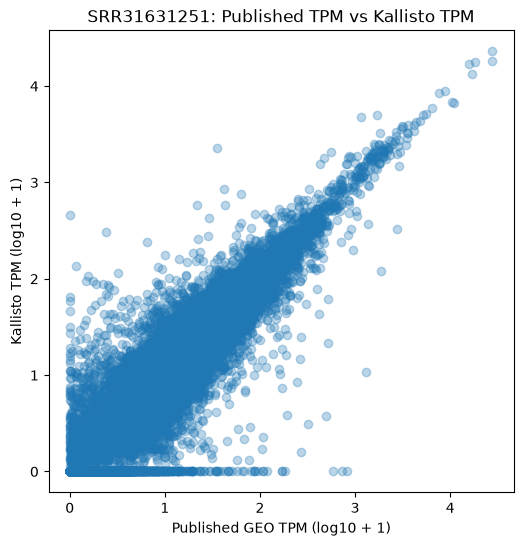

In [35]:
plt.figure(figsize=(6, 6))

plt.scatter(
    np.log10(comparison["geo_tpm"] + 1),
    np.log10(comparison["tpm"] + 1),
    alpha=0.3
)

plt.xlabel("Published GEO TPM (log10 + 1)")
plt.ylabel("Kallisto TPM (log10 + 1)")
plt.title("SRR31631251: Published TPM vs Kallisto TPM")

plt.savefig(
    "results/TPM_comparison_SRR31631251.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
corr = np.corrcoef(
    np.log10(comparison["geo_tpm"] + 1),
    np.log10(comparison["tpm"] + 1)
)[0, 1]

print("Correlation:", corr)

Correlation: 0.9631447699635629


In [39]:
def geo_column_name(condition, replicate):
    if condition == "siCTRL+IFNg":
        base = "siCTRL_with_IFN"
    elif condition == "siCTRL":
        base = "siCTRL_wo_IFN"
    elif condition == "siMITF+IFNg":
        base = "siMITF_with_IFN"
    elif condition == "siMITF":
        base = "siMITF_wo_IFN"

    return f"{base}_{replicate}"

In [41]:
samples["geo_column"] = samples.apply(
    lambda row: geo_column_name(
        row["condition"],
        row["replicate"]
    ),
    axis=1
)

samples[
    ["run_accession", "condition", "replicate", "geo_column"]
]

,run_accession,condition,replicate,geo_column
0,SRR31631262,siCTRL,1,siCTRL_wo_IFN_1
1,SRR31631258,siCTRL,2,siCTRL_wo_IFN_2
2,SRR31631254,siCTRL,3,siCTRL_wo_IFN_3
3,SRR31631261,siCTRL+IFNg,1,siCTRL_with_IFN_1
4,SRR31631257,siCTRL+IFNg,2,siCTRL_with_IFN_2
5,SRR31631253,siCTRL+IFNg,3,siCTRL_with_IFN_3
6,SRR31631260,siMITF,1,siMITF_wo_IFN_1
7,SRR31631256,siMITF,2,siMITF_wo_IFN_2
8,SRR31631252,siMITF,3,siMITF_wo_IFN_3
9,SRR31631259,siMITF+IFNg,1,siMITF_with_IFN_1


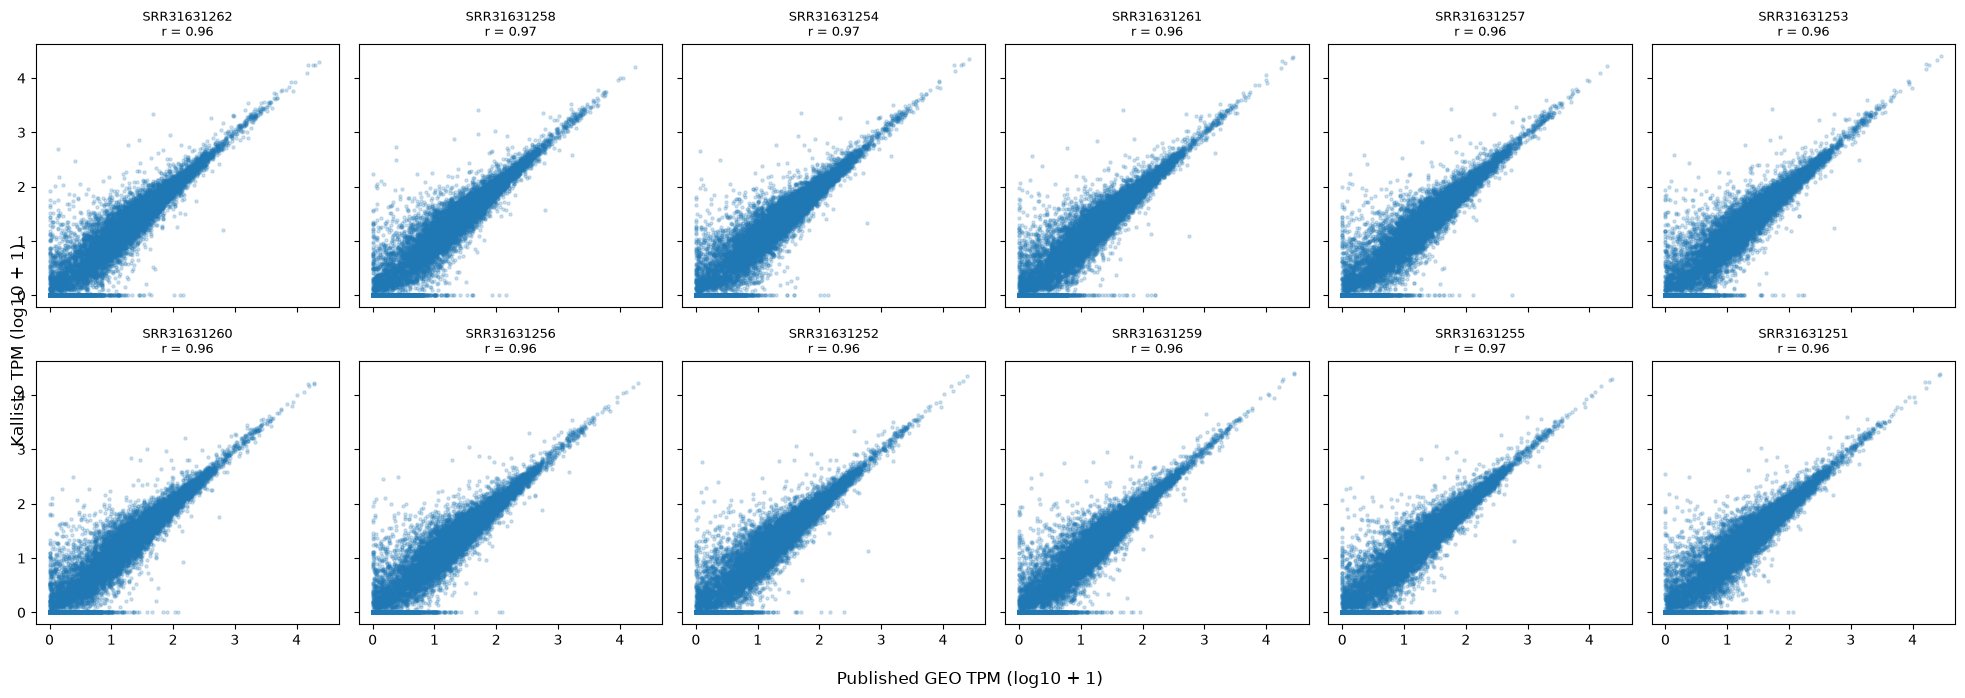

In [44]:
fig, axes = plt.subplots(
    2, 6,
    figsize=(20, 7),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (run, geo_col) in zip(
    axes,
    zip(samples["run_accession"], samples["geo_column"])
):
    # Read kallisto output
    kallisto = pd.read_csv(
        f"data/quant/{run}/abundance.tsv",
        sep="\t"
    )

    # Map transcript → gene
    kallisto_gene = kallisto.merge(
        t2g_small,
        left_on="target_id",
        right_on="transcript_id",
        how="inner"
    )

    # Sum TPM per gene
    kallisto_gene_tpm = (
        kallisto_gene
        .groupby("gene_id", as_index=False)["tpm"]
        .sum()
    )

    # Published TPM for matching sample
    geo_one = geo_tpm[
        ["Unnamed: 0", geo_col]
    ].copy()

    geo_one.columns = ["gene_id", "geo_tpm"]

    # Match genes
    comparison = kallisto_gene_tpm.merge(
        geo_one,
        on="gene_id",
        how="inner"
    )

    # Correlation
    corr = np.corrcoef(
        np.log10(comparison["geo_tpm"] + 1),
        np.log10(comparison["tpm"] + 1)
    )[0, 1]

    # Plot
    ax.scatter(
        np.log10(comparison["geo_tpm"] + 1),
        np.log10(comparison["tpm"] + 1),
        alpha=0.2,
        s=5
    )

    ax.set_title(
        f"{run}\nr = {corr:.2f}",
        fontsize=9
    )

fig.supxlabel("Published GEO TPM (log10 + 1)")
fig.supylabel("Kallisto TPM (log10 + 1)")

plt.tight_layout()




plt.savefig(
    "results/TPM_comparison_all_12_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()